# ADS1002 Group Project – Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_columns', 30)
figure_dir = Path('figures')
figure_dir.mkdir(exist_ok=True)

In [2]:
# Keep the CSV in the same folder as this notebook.
# "None" is a PromoInterval category, not an empty cell.
df = pd.read_csv('modelling.csv', keep_default_na=False, na_values=[''])
df['Date'] = pd.to_datetime(df['Date'], errors='raise')
df.head()

In [3]:
df.shape

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175000 entries, 0 to 174999
Data columns (total 22 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      175000 non-null  int64         
 1   DayOfWeek                  175000 non-null  int64         
 2   Date                       175000 non-null  datetime64[us]
 3   Sales                      175000 non-null  int64         
 4   Customers                  175000 non-null  int64         
 5   Open                       175000 non-null  int64         
 6   Promo                      175000 non-null  int64         
 7   StateHoliday               175000 non-null  int64         
 8   SchoolHoliday              175000 non-null  int64         
 9   StoreType                  175000 non-null  int64         
 10  Assortment                 175000 non-null  int64         
 11  CompetitionDistance        175000 non-null  float64       
 12 

In [5]:
df.describe()

In [6]:
df.isnull().sum()

In [7]:
# Check source types, missingness, duplicate keys and date consistency.
audit = pd.DataFrame({'dtype': df.dtypes.astype(str),
                      'missing': df.isna().sum(),
                      'unique_values': df.nunique(dropna=False)})
display(audit)
print('Exact duplicate rows:', df.duplicated().sum())
print('Duplicate Store-Date pairs:', df.duplicated(['Store', 'Date']).sum())
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Stores:', df['Store'].nunique())
print('Negative Sales / Customers:', (df[['Sales', 'Customers']] < 0).sum().to_dict())
print('Non-finite numeric values:', (~np.isfinite(df.select_dtypes('number'))).sum().sum())
for column, expected in {'Year': df.Date.dt.year, 'Month': df.Date.dt.month,
                         'Day': df.Date.dt.day, 'DayOfWeek': df.Date.dt.dayofweek + 1,
                         'WeekOfYear': df.Date.dt.isocalendar().week}.items():
    print(column, 'date mismatches:', (df[column] != expected).sum())
display(pd.crosstab(df['Promo2'], df['PromoInterval']))
display(df[['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
            'Promo2SinceWeek', 'Promo2SinceYear']].eq(0).sum().to_frame('Zero values'))
print('None interval / Promo2 mismatch:', (df.PromoInterval.eq('None') != df.Promo2.eq(0)).sum())
print('Sales skewness:', round(df.Sales.skew(), 3))
print('Sales quartiles:', df.Sales.quantile([.25,.5,.75]).to_dict())

                                    dtype  missing  unique_values
Store                               int64        0            223
DayOfWeek                           int64        0              7
Date                       datetime64[us]        0            942
Sales                               int64        0          19122
Customers                           int64        0           3991
Open                                int64        0              1
Promo                               int64        0              2
StateHoliday                        int64        0              4
SchoolHoliday                       int64        0              2
StoreType                           int64        0              4
Assortment                          int64        0              3
CompetitionDistance               float64        0            179
CompetitionOpenSinceMonth         float64        0             13
CompetitionOpenSinceYear          float64        0             19
Promo2    

PromoInterval  Feb,May,Aug,Nov  Jan,Apr,Jul,Oct  Mar,Jun,Sept,Dec    None
Promo2                                                                   
0                            0                0                 0  116357
1                        10728            37675             10240       0

                           Zero values
CompetitionOpenSinceMonth        48693
CompetitionOpenSinceYear         48693
Promo2SinceWeek                 116357
Promo2SinceYear                 116357

Exact duplicate rows: 0
Duplicate Store-Date pairs: 0
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Stores: 223
Negative Sales / Customers: {'Sales': 0, 'Customers': 0}
Non-finite numeric values: 0
Year date mismatches: 0
Month date mismatches: 0
Day date mismatches: 0
DayOfWeek date mismatches: 0
WeekOfYear date mismatches: 0
None interval / Promo2 mismatch: 0
Sales skewness: 1.35
Sales quartiles: {0.25: 7885.0, 0.5: 9687.0, 0.75: 12078.0}


# Overall EDA Findings

The updated EDA uses modelling.csv. Each row represents one recorded store-day.

- The dataset contains 175,000 observations, 22 variables and 223 stores from 2013-01-01 to 2015-07-31.
- All records have Open = 1. We cannot compare open and closed stores using this file.
- Sales are right-skewed. Mean sales are 10,409 and median sales are 9,687. Only 7 records have zero sales.
- Customers and Sales have a positive Pearson correlation of 0.755.
- Mean sales are 12,161 with promotions and 9,016 without promotions, an observed difference of 34.9%. This does not establish a causal promotion effect.
- Monday has the highest mean sales (12,160), while Saturday has the lowest (9,067). Sunday has only 2,266 records from 19 stores, so it represents a different store mix.
- Both observed Decembers have higher monthly mean sales than the other months in their respective years.

The project teammate confirmed that modelling.csv contains the top 20% performing stores on recorded open days, not the top 20 stores. The ranking metric and selection period were not supplied. These findings describe this selected sample and do not represent all stores. Category mappings were not supplied.

## Data Overview

**Relationship**

The supplied file contains 175,000 observations and 22 variables. There are no blank cells or duplicate Store-Date pairs. Date is converted from text to datetime; the other imported types are 14 integer columns, 6 floating-point columns and one text column (PromoInterval).

**Insight**

No blank cells does not mean every field is fully known. PromoInterval has 116,357 literal "None" values, all associated with Promo2 = 0. The zero Promo2 start fields also match non-participation. Competition opening month/year are both zero in 48,693 rows (27.8%); these are invalid calendar values and should be treated as unknown pending confirmation of the cleaning rules. Existing imputations cannot be identified from this file alone.

Store is an identifier. StoreType, Assortment and StateHoliday contain category codes, not numeric quantities. Their original label mapping was not supplied, so we retain the codes.

# Sales Distribution

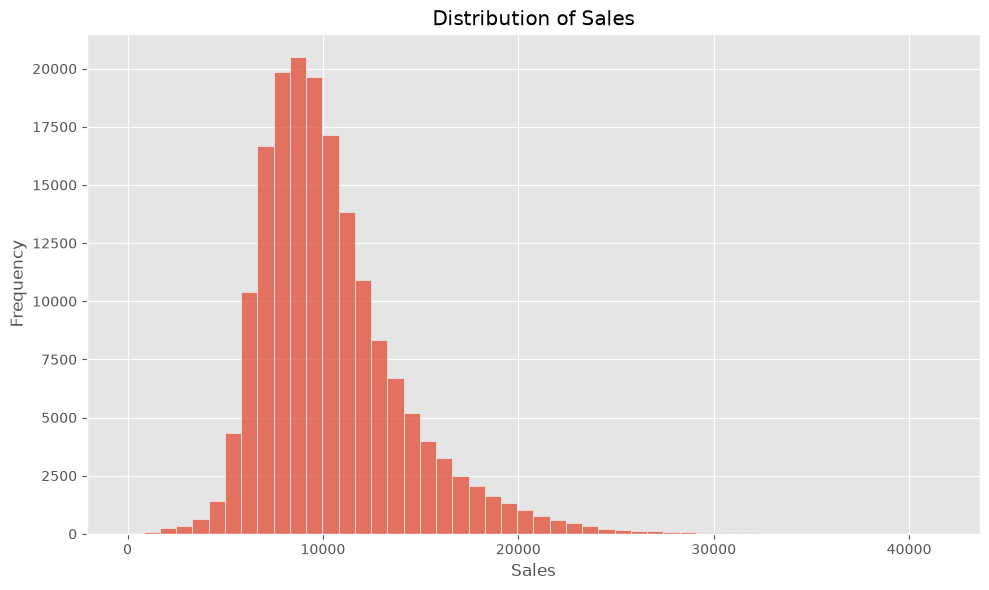

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(df["Sales"], bins=50, kde=False)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(figure_dir / '01_sales_distribution.png', dpi=200)
plt.show()

### Relationship

Sales have a right-skewed distribution (skewness 1.350). Mean sales are 10,409 and median sales are 9,687. The middle 50% lie between 7,885 and 12,078, with a maximum of 41,551.

### Insight

There are only 7 zero-sales observations (0.004%), and all have Open = 1. We should check these records before modelling. High values are not automatically errors, so no outliers are removed here. A log1p target can be compared during model validation, with predictions converted back to the original sales scale.

# Sales by Day of Week

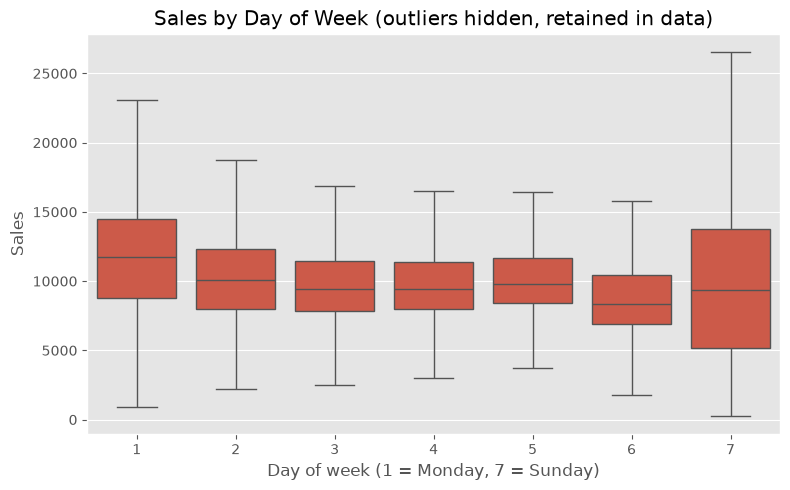

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="DayOfWeek",
    y="Sales",
    order=range(1, 8),
    showfliers=False
)

plt.title("Sales by Day of Week")

plt.xlabel('Day of week (1 = Monday, 7 = Sunday)')
plt.title('Sales by Day of Week (outliers hidden, retained in data)')
plt.tight_layout()
plt.savefig(figure_dir / '02_weekday_boxplot.png', dpi=200)
plt.show()

### Relationship

Monday has the highest median sales (11,744.5), and Saturday has the lowest (8,377). Sunday median sales are 9,353.5. Outlier markers are hidden to make the boxes readable; all records remain in the calculations.

### Insight

The old explanation about Sunday closures does not apply to this file because every row has Open = 1. Only 19 stores have Sunday records, compared with 223 on each other weekday. Weekday differences may partly reflect the mix of stores and promotions.

# Promo vs Sales

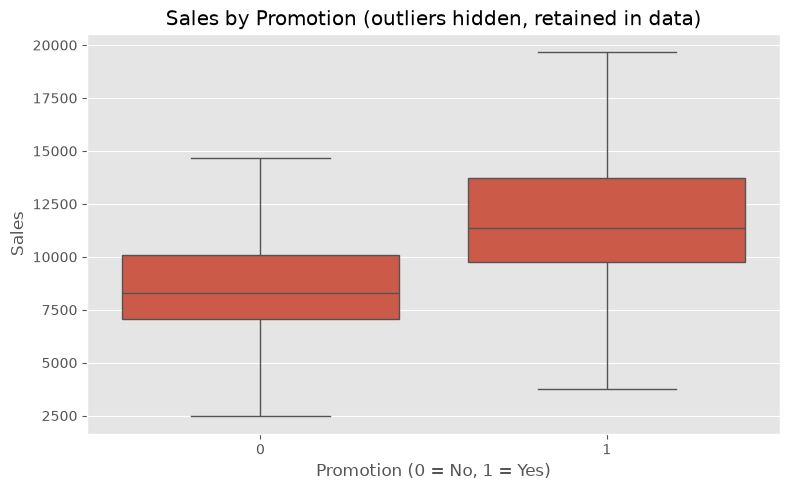

       count      mean   median
Promo                          
0      97452   9015.53   8293.0
1      77548  12160.69  11345.5

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Promo",
    y="Sales",
    showfliers=False
)

plt.title("Sales by Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Sales")

plt.title('Sales by Promotion (outliers hidden, retained in data)')
plt.tight_layout()
plt.savefig(figure_dir / '03_promo_sales.png', dpi=200)
plt.show()
display(df.groupby('Promo')['Sales'].agg(['count', 'mean', 'median']).round(2))

### Relationship

Promotion records have mean sales of 12,160.69 and median sales of 11,345.5 (n = 77,548). Non-promotion records have mean sales of 9,015.53 and median sales of 8,293 (n = 97,452). The mean difference is 3,145.15, or 34.9% relative to non-promotion records.

### Insight

Promotions are associated with higher sales in this sample. This comparison does not control for weekday, season or store differences, so we cannot conclude that promotions caused a 34.9% increase.

# Customers vs Sales

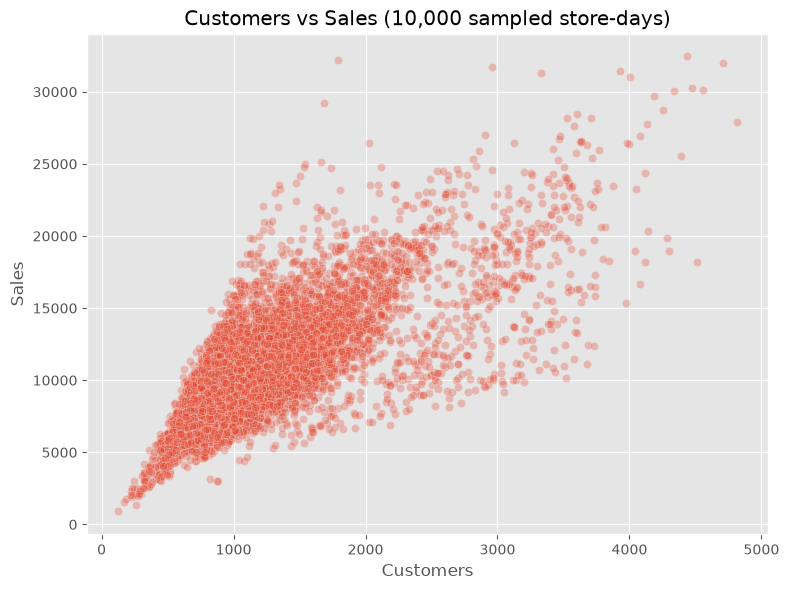

Pearson correlation (all rows): 0.755


In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(n=min(10000, len(df)), random_state=42),
    x="Customers",
    y="Sales",
    alpha=0.3
)

plt.title("Customers vs Sales (10,000 sampled store-days)")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig(figure_dir / '04_customers_sales.png', dpi=200)
plt.show()
print('Pearson correlation (all rows):', round(df['Customers'].corr(df['Sales']), 3))

### Relationship

Customers and Sales have a strong positive relationship, with Pearson r = 0.755 using all 175,000 observations. The scatter plot uses a fixed random sample of 10,000 rows to reduce overplotting.

### Insight

Customer traffic helps explain observed sales. However, actual same-day Customers may not be available when predicting future sales. A forecasting model should exclude it unless it is genuinely known at prediction time. A model using it should be described as a same-day explanatory model and evaluated separately.

# Correlation Heatmap



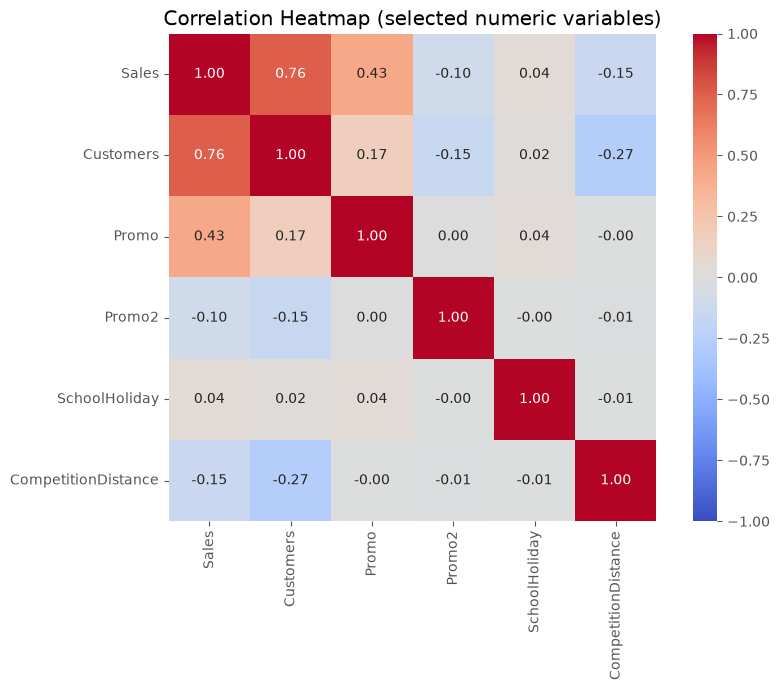

In [12]:
plt.figure(figsize=(9,7))
# Exclude Store IDs, arbitrary category codes, constant Open and sentinel dates.
correlation_columns = ['Sales', 'Customers', 'Promo', 'Promo2',
                       'SchoolHoliday', 'CompetitionDistance']
corr = df[correlation_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Correlation Heatmap (selected numeric variables)')
plt.tight_layout()
plt.savefig(figure_dir / '05_correlation.png', dpi=200)
plt.show()

### Relationship

Sales correlate with Customers (0.755), Promo (0.425), CompetitionDistance (-0.147), Promo2 (-0.098) and SchoolHoliday (0.041). Open has no variance, so its correlation is undefined.

### Insight

These are unadjusted linear associations. Store IDs and arbitrary category codes are excluded because numeric distances between their codes have no useful meaning. Weekday and seasonal patterns are inspected in separate plots. Weak pairwise correlations do not prove that a feature is useless in a nonlinear model.

# Sales by Store Status



In [13]:
# Open is constant in this file, so an open/closed boxplot is not informative.
display(df['Open'].value_counts(dropna=False).rename_axis('Open').to_frame('Count'))
zero_sales = df.loc[df['Sales'].eq(0), ['Store', 'Date', 'Sales', 'Customers', 'Open']]
display(zero_sales)
print('Zero-sales records:', len(zero_sales))

       Count
Open        
1     175000

        Store       Date  Sales  Customers  Open
7050      259 2013-02-07      0          0     1
71461     983 2014-01-17      0          0     1
71683     983 2014-01-18      0          0     1
76356      25 2014-02-12      0          0     1
76579      25 2014-02-13      0          0     1
102056     57 2014-07-01      0          0     1
106280    387 2014-07-24      0          0     1

Zero-sales records: 7


### Relationship

All 175,000 records have Open = 1. Seven records have both zero sales and zero customers despite being marked open.

### Insight

This file cannot estimate the effect of opening status. Open can be removed as a constant predictor for this sample. The seven zero records are retained for inspection because their cause is unknown. Forecasts based on this sample concern recorded open-store days; closure behaviour requires additional data.

# Average Sales by Day of Week


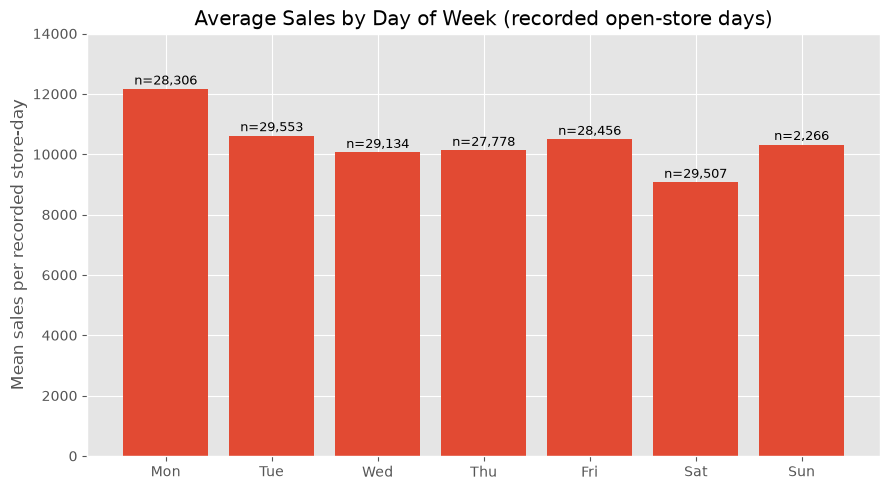

           Count  MeanSales  MedianSales  Stores
DayOfWeek                                       
1          28306   12159.85      11744.5     223
2          29553   10613.06      10077.0     223
3          29134   10057.49       9463.0     223
4          27778   10126.27       9467.0     223
5          28456   10491.15       9820.0     223
6          29507    9067.23       8377.0     223
7           2266   10321.65       9353.5      19

In [14]:
weekday_summary = df.groupby('DayOfWeek').agg(
    Count=('Sales', 'size'), MeanSales=('Sales', 'mean'),
    MedianSales=('Sales', 'median'), Stores=('Store', 'nunique'))
plt.figure(figsize=(9,5))
bars = plt.bar(weekday_summary.index, weekday_summary['MeanSales'])
for bar, count in zip(bars, weekday_summary['Count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'n={count:,}', ha='center', fontsize=9)
plt.xticks(range(1,8), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.ylim(0, 14000)
plt.title('Average Sales by Day of Week (recorded open-store days)')
plt.ylabel('Mean sales per recorded store-day')
plt.tight_layout()
plt.savefig(figure_dir / '06_weekday_means.png', dpi=200)
plt.show()
display(weekday_summary.round(2))

### Relationship

Monday has the highest average sales (12,159.85), followed by Tuesday (10,613.06). Saturday has the lowest (9,067.23). Sunday averages 10,321.65, based on only 2,266 records.

### Insight

Day of week is worth considering in modelling, but Sunday should not be described as the lowest-sales day. Its 19-store sample differs from the other weekdays. The bars show descriptive means without confidence intervals because store-day observations are repeated within stores.

# Sales by Store Type and Assortment

            Count  Stores  MeanSales  MedianSales
StoreType                                        
0          101875     131   10559.31       9831.0
1           11270      12   11992.32      11046.0
2           22587      29   10210.88       9575.0
3           39268      51    9679.70       9200.0

            Count  Stores  MeanSales  MedianSales
Assortment                                       
0           74669      95   10280.20       9587.0
1            4676       5   10982.36      10726.5
2           95655     123   10481.97       9716.0

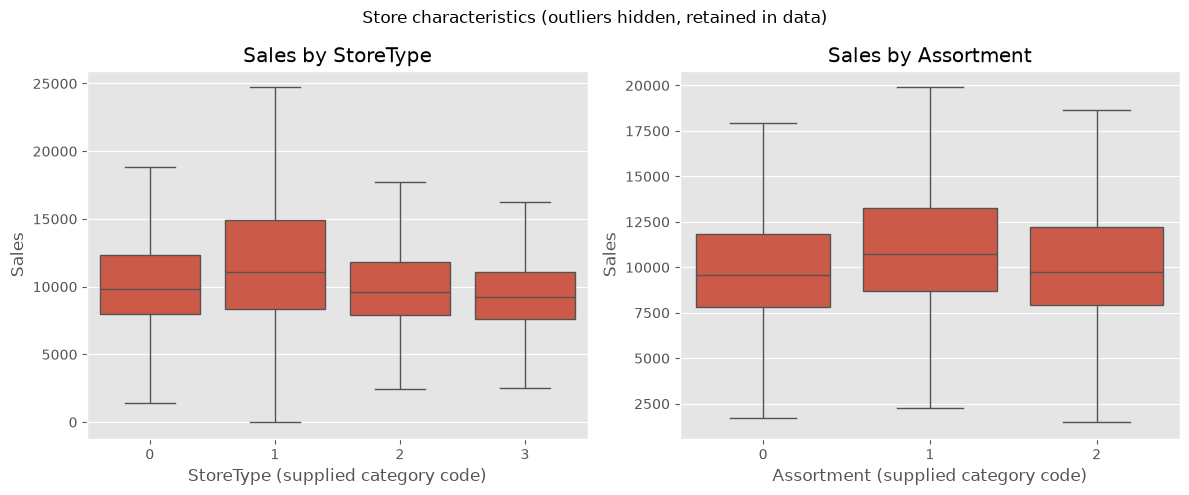

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, column in zip(axes, ['StoreType', 'Assortment']):
    sns.boxplot(data=df, x=column, y='Sales', showfliers=False, ax=ax)
    ax.set_title('Sales by ' + column)
    ax.set_xlabel(column + ' (supplied category code)')
    display(df.groupby(column).agg(Count=('Sales','size'),
                                   Stores=('Store','nunique'),
                                   MeanSales=('Sales','mean'),
                                   MedianSales=('Sales','median')).round(2))
fig.suptitle('Store characteristics (outliers hidden, retained in data)')
plt.tight_layout()
plt.savefig(figure_dir / '07_store_characteristics.png', dpi=200)
plt.show()

### Relationship

StoreType code 1 has the highest mean sales (11,992), while code 3 has the lowest (9,680). Assortment means range from 10,280 (code 0) to 10,982 (code 1), with overlapping distributions.

### Insight

Store characteristics may help prediction. Treat these fields as categories, not ordered quantities. Code meanings need the team's encoding map. These comparisons are weighted by recorded store-days, and group sizes differ.

# Sales Over Time

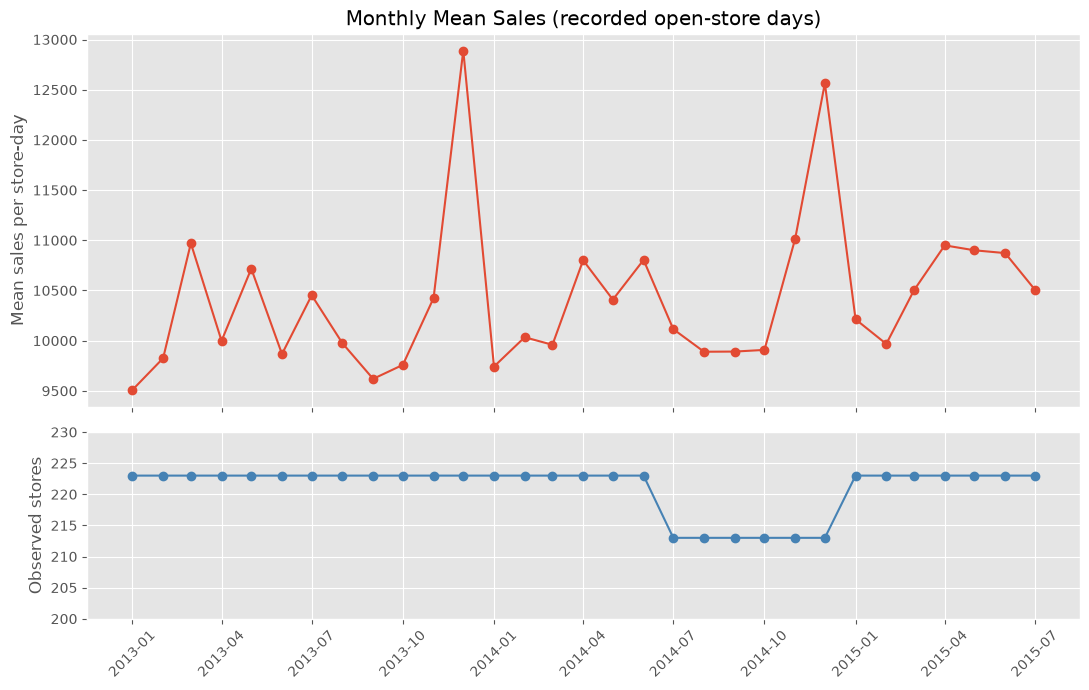

         MeanSales  Count  Stores
Date                             
2013-01    9509.16   5839     223
2013-02    9825.20   5381     223
2013-03   10970.26   5648     223
2013-04    9998.29   5670     223
2013-05   10717.14   5365     223
2013-06    9866.97   5659     223
2013-07   10452.20   6084     223
2013-08    9974.67   6080     223
2013-09    9619.40   5665     223
2013-10    9758.94   5867     223
2013-11   10423.97   5743     223
2013-12   12890.66   5448     223
2014-01    9741.91   5810     223
2014-02   10034.10   5388     223
2014-03    9958.83   5855     223
2014-04   10801.02   5459     223
2014-05   10408.78   5682     223
2014-06   10804.30   5346     223
2014-07   10114.68   5801     213
2014-08    9889.77   5633     213
2014-09    9891.37   5614     213
2014-10    9908.01   5605     213
2014-11   11014.13   5293     213
2014-12   12564.30   5408     213
2015-01   10212.56   5830     223
2015-02    9967.39   5388     223
2015-03   10502.42   5878     223
2015-04   1094

In [16]:
monthly = df.groupby(df['Date'].dt.to_period('M')).agg(
    MeanSales=('Sales','mean'), Count=('Sales','size'), Stores=('Store','nunique'))
fig, axes = plt.subplots(2, 1, figsize=(11,7), sharex=True,
                         gridspec_kw={'height_ratios':[2,1]})
dates = monthly.index.to_timestamp()
axes[0].plot(dates, monthly['MeanSales'], marker='o')
axes[0].set_title('Monthly Mean Sales (recorded open-store days)')
axes[0].set_ylabel('Mean sales per store-day')
axes[1].plot(dates, monthly['Stores'], marker='o', color='steelblue')
axes[1].set_ylabel('Observed stores')
axes[1].set_ylim(200,230)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(figure_dir / '08_monthly_sales.png', dpi=200)
plt.show()
display(monthly.round(2))

### Relationship

December mean sales are 12,890.66 in 2013 and 12,564.30 in 2014, the highest monthly means in each observed full year. The sample contains 213 stores per month in July–December 2014, compared with 223 in other months.

### Insight

The two December peaks suggest a seasonal pattern worth testing. The chart uses mean sales per recorded store-day because monthly totals depend on record counts. Means can still change with the store mix. We only have data through July 2015, so full-year totals are not directly comparable.

# Implications for Modelling

- **Target and scope:** predict Sales for recorded open-store days. Keep the seven zero-sales records visible until the team decides how to handle them.
- **Availability:** exclude actual same-day Customers for future forecasting unless it is known at prediction time. Compare a separate explanatory model if the project requires Customers.
- **Features:** remove constant Open. Treat Store, StoreType, Assortment, StateHoliday and weekday as categorical where appropriate. Store is an identifier, not a continuous measure. Keep codes until the original mapping is confirmed.
- **Missing values:** treat zero competition opening month/year as unknown, and preserve the distinction between missing information and non-participation in Promo2. Confirm any previous imputation with the cleaning notebook. Promo2 indicates programme participation, not necessarily an active promotion on every row.
- **Validation:** for future forecasting, split by date, placing all stores on the same date in the same partition. Fit encoders, imputers and scalers using training data only. Use a store-held-out split if the goal is prediction for unseen stores. This EDA describes the full supplied file, so it is not evidence of model performance on untouched test data.
- **Models:** use a simple baseline and the same evaluation split for regression, KNN and neural networks. Scale numeric predictors for KNN and neural networks, and encode nominal categories. Assess MAE and RMSE on the original Sales scale. Ordinary MAPE is undefined for the seven zero-sales records.
- **Interpretation:** repeated rows within stores are not independent. Associations in this EDA do not establish causal effects. Validate feature and transformation choices rather than deciding from pairwise correlation alone.

# Additional EDA for the mock presentation

The project teammate confirmed that modelling.csv contains the top 20% performing stores on recorded open days, not the top 20 stores. The ranking metric and selection period were not supplied. These findings describe this selected sample and do not represent all stores.

In [17]:
# Presentation settings for the additional figures
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 16})
def save_extra(name):
    plt.tight_layout()
    plt.savefig(figure_dir / name, dpi=240, bbox_inches='tight')
    plt.show()


# Customer Distribution

**Relationship**

Explore how customer counts vary across recorded store-days.

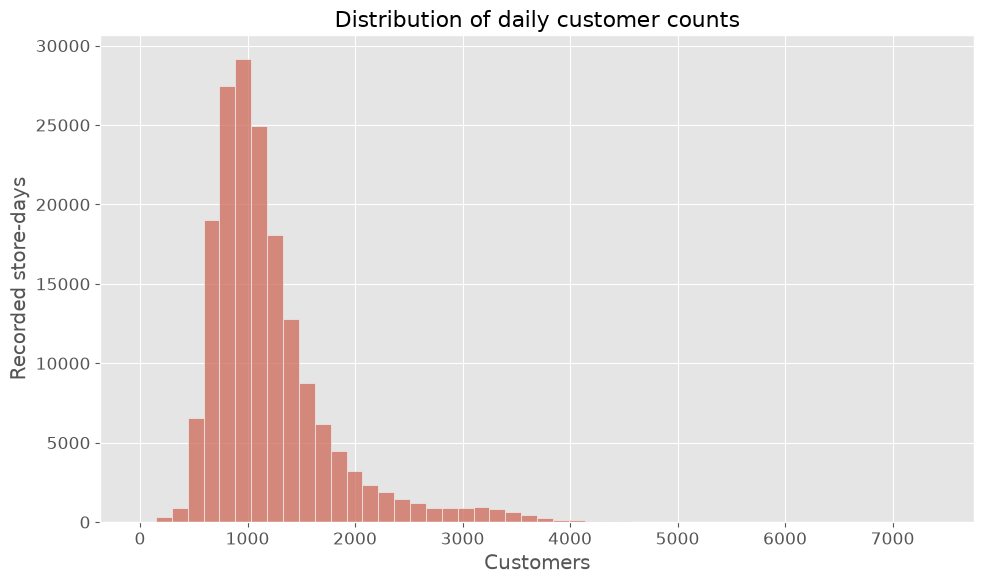

Mean customers: 1,201; median: 1,057


In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Customers', bins=50, color='#ce6958')
plt.title('Distribution of daily customer counts')
plt.ylabel('Recorded store-days')
save_extra('09_customer_distribution.png')
print(f"Mean customers: {df.Customers.mean():,.0f}; median: {df.Customers.median():,.0f}")


**Insight**

Compare the mean and median with the histogram. This describes footfall, while the Customers–Sales scatterplot asks how footfall relates to revenue. Actual daily customer counts may be unknown when forecasting future sales.

# Promotion and Day of Week

**Relationship**

Compare promotion and non-promotion records within each weekday.

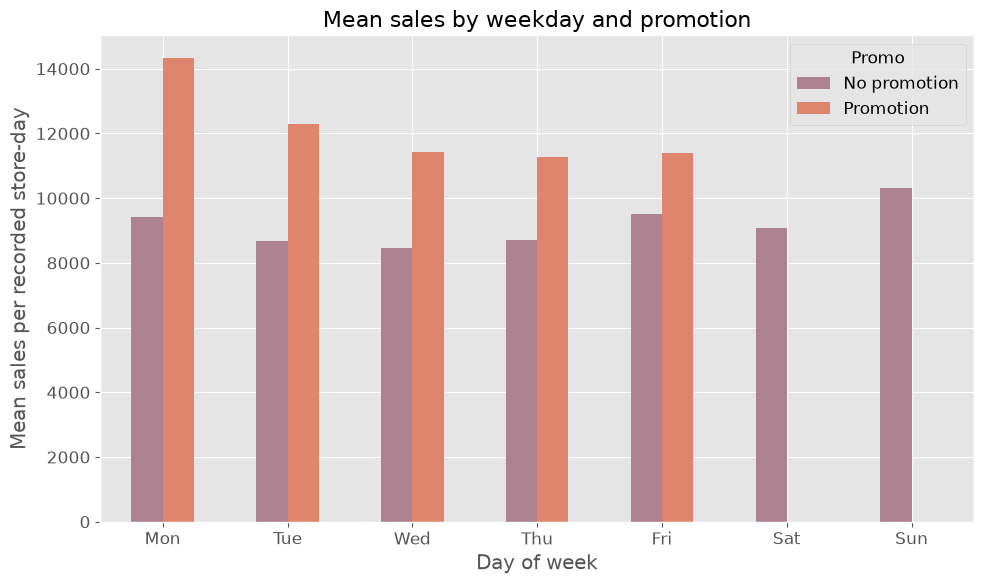

    DayOfWeek  Promo          mean   size
0           1      0   9414.487192  12453
1           1      1  14316.421498  15853
2           2      0   8666.650190  13696
3           2      1  12294.213344  15857
4           3      0   8468.996883  13474
5           3      1  11424.243103  15660
6           4      0   8697.085368  12452
7           4      1  11287.445778  15326
8           5      0   9504.684431  13604
9           5      1  11394.717210  14852
10          6      0   9067.225675  29507
11          7      0  10321.650044   2266

In [19]:
promo_day = df.groupby(['DayOfWeek', 'Promo']).Sales.agg(['mean','size']).reset_index()
table = promo_day.pivot(index='DayOfWeek', columns='Promo', values='mean').reindex(range(1,8))
ax=table.rename(columns={0:'No promotion',1:'Promotion'}).plot.bar(figsize=(10,6),color=['#ac8290','#df856d'],rot=0)
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title('Mean sales by weekday and promotion')
plt.xlabel('Day of week'); plt.ylabel('Mean sales per recorded store-day')
save_extra('10_promotion_weekday.png')
display(promo_day)


**Insight**

Only compare pairs with observations in both groups. A missing bar means there were no records in that combination, not zero sales. Differences within weekdays still mix stores, seasons and other factors, so they do not establish a causal promotion effect.

# School Holidays and Sales

**Relationship**

Compare sales distributions for school-holiday and other recorded days.

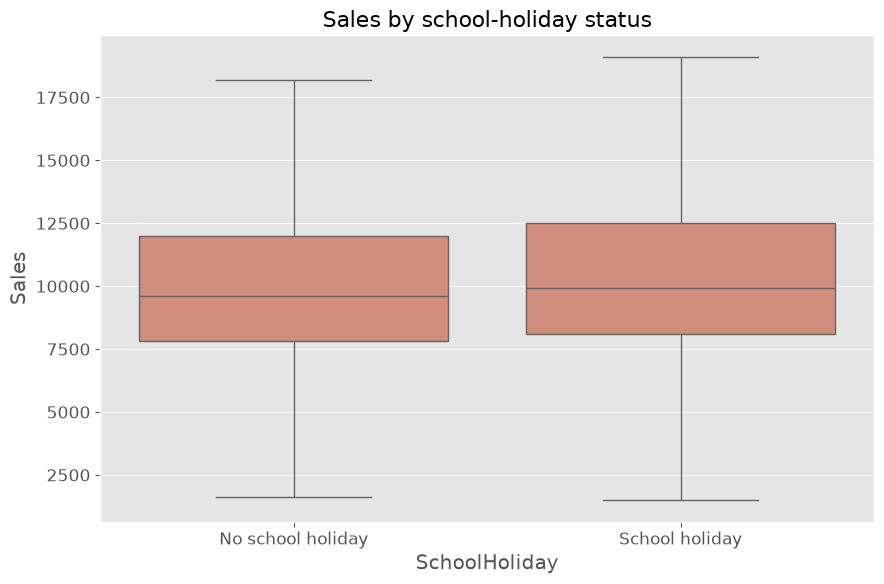

                 size          mean  median
SchoolHoliday                              
0              140692  10334.513626  9626.0
1               34308  10715.727993  9940.0

In [20]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df,x='SchoolHoliday',y='Sales',order=[0,1],showfliers=False,color='#df856d')
plt.xticks([0,1],['No school holiday','School holiday'])
plt.title('Sales by school-holiday status')
plt.xlabel('SchoolHoliday'); plt.ylabel('Sales')
save_extra('11_school_holiday.png')
display(df.groupby('SchoolHoliday').Sales.agg(['size','mean','median']))


**Insight**

Boxplots show medians and spread; the table also reports group sizes and means. Outlier markers are hidden, but no records are removed. Holiday comparisons are observational and can reflect differences in dates and stores.

# Differences Between Stores

**Relationship**

Give each store one observation: its mean sales over its available recorded open days.

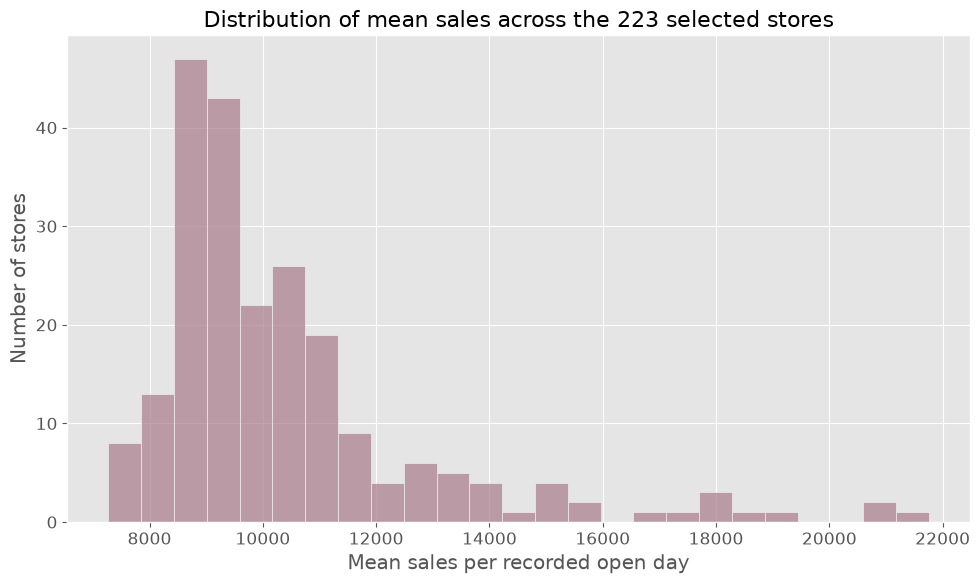

count      223.000000
mean     10419.272731
std       2490.014881
min       7272.454352
25%       8804.939548
50%       9638.401786
75%      11023.683253
max      21757.483418
Name: Sales, dtype: float64

In [21]:
store_means=df.groupby('Store').Sales.mean()
plt.figure(figsize=(10,6))
sns.histplot(store_means,bins=25,color='#ac8290')
plt.title('Distribution of mean sales across the 223 selected stores')
plt.xlabel('Mean sales per recorded open day'); plt.ylabel('Number of stores')
save_extra('12_store_mean_distribution.png')
display(store_means.describe())


**Insight**

Selected stores can still differ substantially in typical daily sales. This figure weights stores equally, unlike the original store-day histogram. Observation periods differ between stores. It does not recreate the teammate’s top-20% ranking.

# Figures for the mock presentation

Use the accompanying Chinese guide for the recommended order and English speaking points. There are 12 image files, including the original 8. The weekday boxplot is a backup because it overlaps with the weekday mean chart. Keep the sample scope visible and describe associations rather than causal effects.